In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df_categories = pd.read_csv('D:\ML_innovise\item_categories.csv')
df_items = pd.read_csv('D:\ML_innovise\items.csv')
df_sales_train = pd.read_csv('D:\ML_innovise\sales_train.csv')
df_submission = pd.read_csv('D:\ML_innovise\sample_submission.csv')
df_shops = pd.read_csv('D:\ML_innovise\shops.csv')
df_testt = pd.read_csv(r'D:\ML_innovise\test.csv')


In [3]:
df= df_items.merge(
    df_categories,
    on='item_category_id',
    how='left',     
    validate='many_to_one'
)


In [4]:
df_1 = df_sales_train.merge(
    df,
    on='item_id',
    how='left',     
    validate='many_to_one'
)


In [5]:
# df_1 - датасет, который содержит вообще всю информацию про продаваемость товаров за весь период 

df_1 = df_1.merge(
    df_shops,
    on='shop_id',
    how='left',     
    validate='many_to_one'
)
df_1.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name
0,02.01.2013,0,59,22154,999.00,1.0,ЯВЛЕНИЕ 2012 (BD),37,Кино - Blu-Ray,"Ярославль ТЦ ""Альтаир"""
1,03.01.2013,0,25,2552,899.00,1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум"""
2,05.01.2013,0,25,2552,899.00,-1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум"""
3,06.01.2013,0,25,2554,1709.05,1.0,DEEP PURPLE Who Do You Think We Are LP,58,Музыка - Винил,"Москва ТРК ""Атриум"""
4,15.01.2013,0,25,2555,1099.00,1.0,DEEP PURPLE 30 Very Best Of 2CD (Фирм.),56,Музыка - CD фирменного производства,"Москва ТРК ""Атриум"""


In [6]:
df_1.isnull().sum() # убедимся, что нет пропусков

date                  0
date_block_num        0
shop_id               0
item_id               0
item_price            0
item_cnt_day          0
item_name             0
item_category_id      0
item_category_name    0
shop_name             0
dtype: int64

In [7]:
df_1.describe()

,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_category_id
count,2.935849e+06,2.935849e+06,2.935849e+06,2.935849e+06,2.935849e+06,2.935849e+06
mean,1.456991e+01,3.300173e+01,1.019723e+04,8.908532e+02,1.242641e+00,4.000138e+01
std,9.422988e+00,1.622697e+01,6.324297e+03,1.729800e+03,2.618834e+00,1.710076e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,-2.200000e+01,0.000000e+00
25%,7.000000e+00,2.200000e+01,4.476000e+03,2.490000e+02,1.000000e+00,2.800000e+01
50%,1.400000e+01,3.100000e+01,9.343000e+03,3.990000e+02,1.000000e+00,4.000000e+01
75%,2.300000e+01,4.700000e+01,1.568400e+04,9.990000e+02,1.000000e+00,5.500000e+01
max,3.300000e+01,5.900000e+01,2.216900e+04,3.079800e+05,2.169000e+03,8.300000e+01


In [8]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2935849 entries, 0 to 2935848
Data columns (total 10 columns):
 #   Column              Dtype  
---  ------              -----  
 0   date                object 
 1   date_block_num      int64  
 2   shop_id             int64  
 3   item_id             int64  
 4   item_price          float64
 5   item_cnt_day        float64
 6   item_name           object 
 7   item_category_id    int64  
 8   item_category_name  object 
 9   shop_name           object 
dtypes: float64(2), int64(4), object(4)
memory usage: 224.0+ MB


In [9]:
df_2 = df_testt.merge(
    df,
    on='item_id',
    how='left',     
    validate='many_to_one'
)


In [10]:
# df_2 - датасет, который содержит всю информацию про товары, продаваемость которых мы будем предсказывать
df_2 = df_2.merge(
    df_shops,
    on='shop_id',
    how='left',     
    validate='many_to_one'
)
df_2.head()

,ID,shop_id,item_id,item_name,item_category_id,item_category_name,shop_name
0,0,5,5037,"NHL 15 [PS3, русские субтитры]",19,Игры - PS3,"Вологда ТРЦ ""Мармелад"""
1,1,5,5320,ONE DIRECTION Made In The A.M.,55,Музыка - CD локального производства,"Вологда ТРЦ ""Мармелад"""
2,2,5,5233,"Need for Speed Rivals (Essentials) [PS3, русск...",19,Игры - PS3,"Вологда ТРЦ ""Мармелад"""
3,3,5,5232,"Need for Speed Rivals (Classics) [Xbox 360, ру...",23,Игры - XBOX 360,"Вологда ТРЦ ""Мармелад"""
4,4,5,5268,"Need for Speed [PS4, русская версия]",20,Игры - PS4,"Вологда ТРЦ ""Мармелад"""


In [11]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214200 entries, 0 to 214199
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   ID                  214200 non-null  int64 
 1   shop_id             214200 non-null  int64 
 2   item_id             214200 non-null  int64 
 3   item_name           214200 non-null  object
 4   item_category_id    214200 non-null  int64 
 5   item_category_name  214200 non-null  object
 6   shop_name           214200 non-null  object
dtypes: int64(4), object(3)
memory usage: 11.4+ MB


In [12]:
df_2.describe()

,ID,shop_id,item_id,item_category_id
count,214200.000000,214200.000000,214200.000000,214200.000000
mean,107099.500000,31.642857,11019.398627,46.309608
std,61834.358168,17.561933,6252.644590,16.716581
min,0.000000,2.000000,30.000000,0.000000
25%,53549.750000,16.000000,5381.500000,37.000000
50%,107099.500000,34.500000,11203.000000,43.000000
75%,160649.250000,47.000000,16071.500000,58.000000
max,214199.000000,59.000000,22167.000000,83.000000


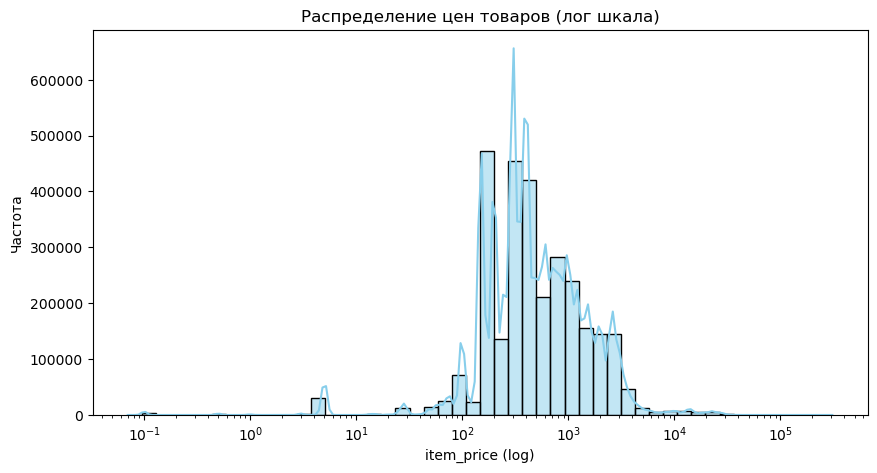

In [13]:
# распределение цены (в лог шкале )
plt.figure(figsize=(10, 5))
sns.histplot(df_1['item_price'],
             bins=50,
             kde=True,
             color='skyblue',
             edgecolor='black',
             log_scale=(True, False)) 
plt.title('Распределение цен товаров (лог шкала)')
plt.xlabel('item_price (log)')
plt.ylabel('Частота')
plt.show()


<Axes: ylabel='item_price'>

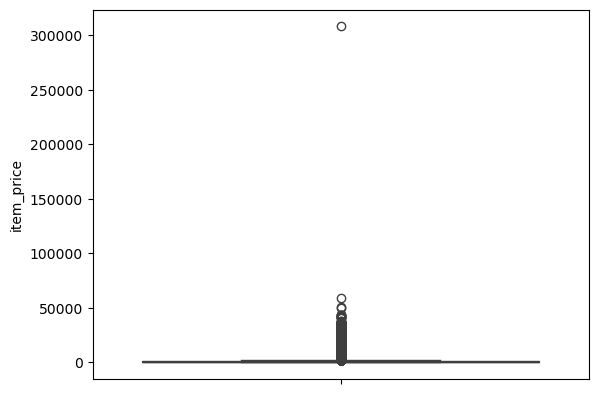

In [14]:
sns.boxplot(df_1['item_price'])


In [15]:
# сначала разберемся. что же за выбросы в цене товара
rich_items = df_1[df_1['item_price'] > 100_000]
(len(rich_items))
rich_items.head(5)

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name
1163158,13.12.2013,11,12,6066,307980.0,1.0,Radmin 3 - 522 лиц.,75,Программы - Для дома и офиса,Интернет-магазин ЧС


In [16]:
# поскольку ошибка в этом товаре произошла один раз, товар вообще продавался один раз всю историю и предсказывать его продаваемость не будем - удаляем 
df_1 = df_1[df_1['item_id'] != 6066]


<Axes: ylabel='item_price'>

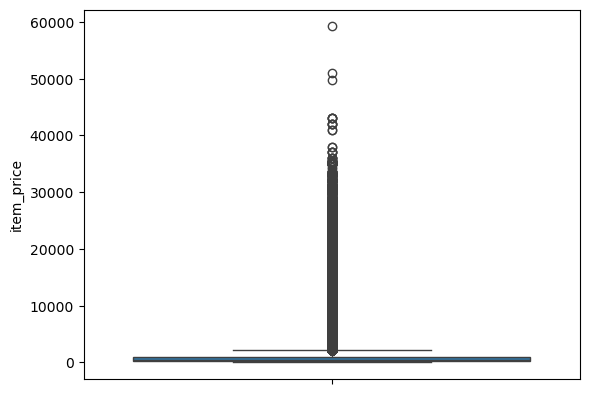

In [17]:
sns.boxplot(df_1['item_price'])# убедились, что стало лучше

In [18]:
selected = df_1[df_1['item_price']<0]
selected

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name
484683,15.05.2013,4,32,2973,-1.0,1.0,"DmC Devil May Cry [PS3, русские субтитры]",19,Игры - PS3,"Москва ТЦ ""Серебряный Дом"""


In [19]:
df_1 = df_1[df_1['item_price']>0] # убрала товары с отрицательной ценой, с выбросами с item_price разобрались

<Axes: ylabel='item_cnt_day'>

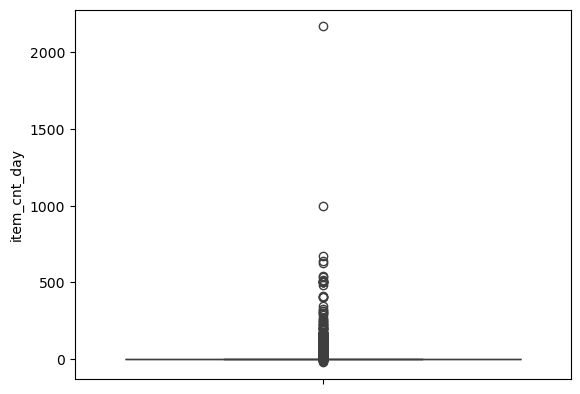

In [20]:
sns.boxplot(df_1['item_cnt_day'])

In [21]:
selected = df_1[df_1['item_cnt_day'] > 900]
selected


,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name
2326930,15.01.2015,24,12,20949,4.000000,1000.0,Фирменный пакет майка 1С Интерес белый (34*42)...,71,"Подарки - Сумки, Альбомы, Коврики д/мыши",Интернет-магазин ЧС
2909818,28.10.2015,33,12,11373,0.908714,2169.0,Доставка до пункта выдачи (Boxberry),9,Доставка товара,Интернет-магазин ЧС


In [22]:
df_1 = df_1[df_1['item_cnt_day'] <= 900] # удаляю выбросы в item_cnt_day

<Axes: ylabel='item_cnt_day'>

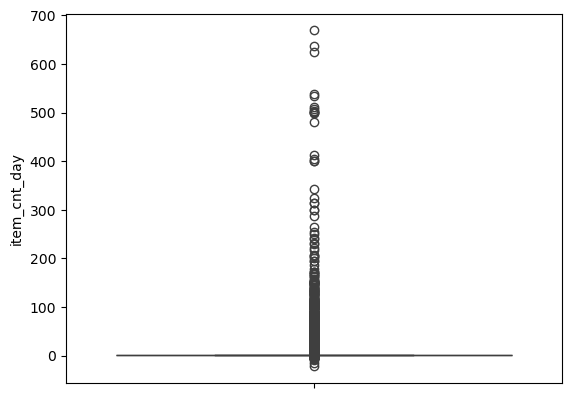

In [23]:
sns.boxplot(df_1['item_cnt_day'])


In [24]:
# поскольку предсказание идет о продажах за месяц, а не за день, могу сгруппировать и избавиться от лишних признаков 
df_month = (
    df_1
    .groupby(
        ['shop_id', 'item_id', 'date_block_num','item_category_id'],
        as_index=False
    )
    .agg({
        'item_price':  'mean',    
        'item_cnt_day':'sum'      
    })
)

df_month = df_month.rename(
    columns={'item_cnt_day': 'item_cnt_month'}
)

df_month = df_month[
    ['item_id','shop_id','item_price','date_block_num','item_cnt_month','item_category_id']
]

df_month.head()


,item_id,shop_id,item_price,date_block_num,item_cnt_month,item_category_id
0,30,0,265.0,1,31.0,40
1,31,0,434.0,1,11.0,37
2,32,0,221.0,0,6.0,40
3,32,0,221.0,1,10.0,40
4,33,0,347.0,0,3.0,37


<Axes: ylabel='item_cnt_month'>

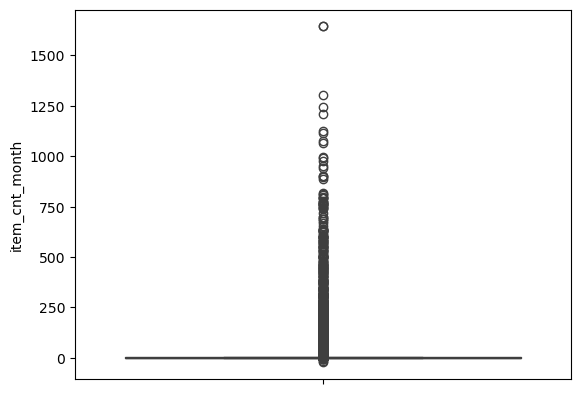

In [25]:
sns.boxplot(df_month['item_cnt_month'])

Тут я хочу проверить и убедиться, какие есть выбросы в item_cnt_month:
- два значения экстремальные
- отрицательные продажи (их много)

In [26]:
selected = df_month[df_month['item_cnt_month']>1500]
selected

,item_id,shop_id,item_price,date_block_num,item_cnt_month,item_category_id
197728,9248,12,1508.318762,32,1644.0,80
1439162,9249,55,1506.993991,32,1644.0,8


In [27]:
selected = df_month[df_month['item_cnt_month']<0]
selected

,item_id,shop_id,item_price,date_block_num,item_cnt_month,item_category_id
9329,1915,2,249.0,9,-1.0,30
10391,2854,2,199.0,15,-1.0,30
10891,3158,2,1290.0,1,-1.0,75
13482,4907,2,1499.0,12,-1.0,23
15072,6457,2,599.0,7,-1.0,30
...,...,...,...,...,...,...
1594220,7299,59,399.0,16,-1.0,55
1600162,13501,59,5790.0,0,-1.0,13
1601784,14931,59,699.0,0,-2.0,69
1604883,17346,59,169.0,18,-1.0,40


In [28]:
# убедимся, что если уберем эти выбросы - это не единственная запись о продаже данного товара в данном магазине
df_11 = df_1[(df_1['item_id']==9248) & (df_1['shop_id']==12) & (df_1['date_block_num']==32)]
df_11.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name
2864235,30.09.2015,32,12,9248,1692.526158,669.0,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) [...",80,Служебные - Билеты,Интернет-магазин ЧС
2864260,29.09.2015,32,12,9248,1500.000000,504.0,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) [...",80,Служебные - Билеты,Интернет-магазин ЧС
2864262,28.09.2015,32,12,9248,1500.000000,139.0,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) [...",80,Служебные - Билеты,Интернет-магазин ЧС
2864263,26.09.2015,32,12,9248,1500.000000,57.0,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) [...",80,Служебные - Билеты,Интернет-магазин ЧС
2864265,01.09.2015,32,12,9248,1500.000000,3.0,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) [...",80,Служебные - Билеты,Интернет-магазин ЧС


In [29]:
df_11 = df_1[(df_1['item_id']==9249) & (df_1['shop_id']==55) & (df_1['date_block_num']==32)]
df_11.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name
2851022,01.09.2015,32,55,9249,1500.0,3.0,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) У...",8,Билеты (Цифра),Цифровой склад 1С-Онлайн
2851023,02.09.2015,32,55,9249,1500.0,3.0,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) У...",8,Билеты (Цифра),Цифровой склад 1С-Онлайн
2851024,03.09.2015,32,55,9249,1500.0,1.0,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) У...",8,Билеты (Цифра),Цифровой склад 1С-Онлайн
2851025,04.09.2015,32,55,9249,1500.0,1.0,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) У...",8,Билеты (Цифра),Цифровой склад 1С-Онлайн
2851026,06.09.2015,32,55,9249,1500.0,5.0,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) У...",8,Билеты (Цифра),Цифровой склад 1С-Онлайн


Видим, что записей о продаже данных товара много, так что если удалим эти две строки с выбросами, нам все равно будет на чем строить предсказания

In [30]:
df_month = df_month[df_month['item_cnt_month']<1500]


<Axes: ylabel='item_cnt_month'>

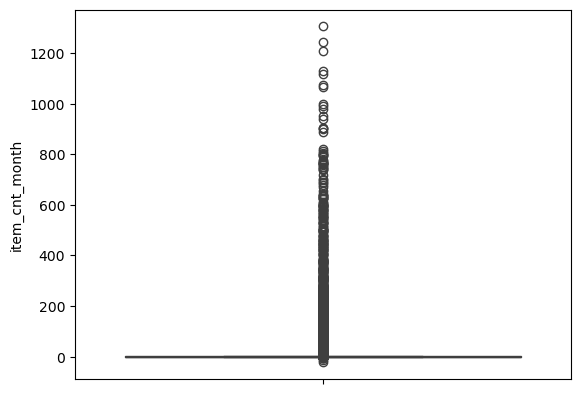

In [31]:
sns.boxplot(df_month['item_cnt_month'])

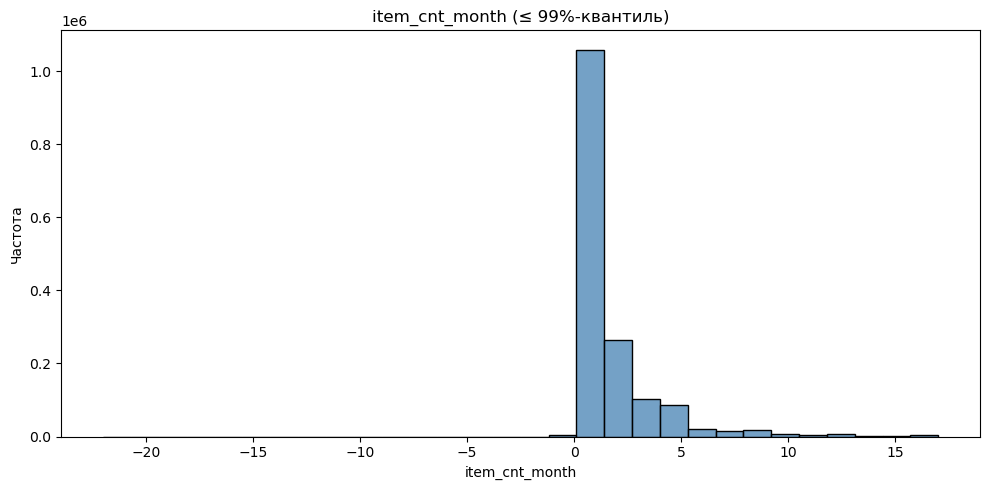

In [32]:
q99 = df_month['item_cnt_month'].quantile(0.99)
df_cut = df_month[df_month['item_cnt_month'] <= q99]

plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_cut,
    x='item_cnt_month',
    bins=30,
    kde=False,
    color='steelblue'
)
plt.title(f'item_cnt_month (≤ 99%-квантиль)')
plt.xlabel('item_cnt_month')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()


Далее, чтобы оставить в правильном диапозоне предсказания нашей модели - нужно учесть строку на кагле:
"True target values are clipped into [0,20] range"
Поскольку нам нужно, чтобы модель давала предсказания в диапозоне от 0 до 20, нужно и чтобы обучалась она на данных в соответственно в таком же диапозоне,
поэтому придется для таргета сделать clipping[0,20]

In [33]:
df_month['item_cnt_month'] = df_month['item_cnt_month'].clip(lower=0, upper=20)

Далее начнем чекать магазины

In [34]:
#from Scripts.src1 import clean_name

import re
def clean_name(s):
    s = s.lower().strip()
    s = re.sub(r"[^а-яa-z0-9\s]", "", s)
    return s

In [35]:
df_shops['shop_clean'] = df_shops['shop_name'].apply(clean_name)

In [36]:
sorted_shops = df_shops['shop_clean'].sort_values()
print(sorted_shops.to_list())

['адыгея тц мега', 'балашиха трк октябрькиномир', 'волжский тц волга молл', 'вологда трц мармелад', 'воронеж плехановская 13', 'воронеж трц максимир', 'воронеж трц ситипарк град', 'выездная торговля', 'жуковский ул чкалова 39м', 'жуковский ул чкалова 39м', 'интернетмагазин чс', 'казань тц бехетле', 'казань тц паркхаус ii', 'калуга трц xxi век', 'коломна тц рио', 'красноярск тц взлетка плаза', 'красноярск тц июнь', 'курск тц пушкинский', 'москва магазин с21', 'москва мтрц афи молл', 'москва распродажа', 'москва тк буденовский пава2', 'москва тк буденовский павк7', 'москва трк атриум', 'москва тц ареал беляево', 'москва тц мега белая дача ii', 'москва тц мега теплый стан ii', 'москва тц новый век новокосино', 'москва тц перловский', 'москва тц семеновский', 'москва тц серебряный дом', 'мытищи трк xl3', 'нновгород трц рио', 'нновгород трц фантастика', 'новосибирск трц галерея новосибирск', 'новосибирск тц мега', 'омск тц мега', 'ростовнадону трк мегацентр горизонт', 'ростовнадону трк мега

Вызывающие сомнения магазины:

'ростовнадону трк мегацентр горизонт', 'ростовнадону трк мегацентр горизонт островной', 'ростовнадону тц мега'

'якутск орджоникидзе 56', 'якутск орджоникидзе 56 фран'

'жуковский ул. чкалова 39м', 'жуковский ул. чкалова 39м'

С моей точки зрения, это могут быть одни и те же магазины, но нужно проверить статистически

In [37]:
df_11 = df_1[df_1['shop_id']==39]
df_22= df_1[df_1['shop_id']==40]
df_33= df_1[df_1['shop_id']==41]

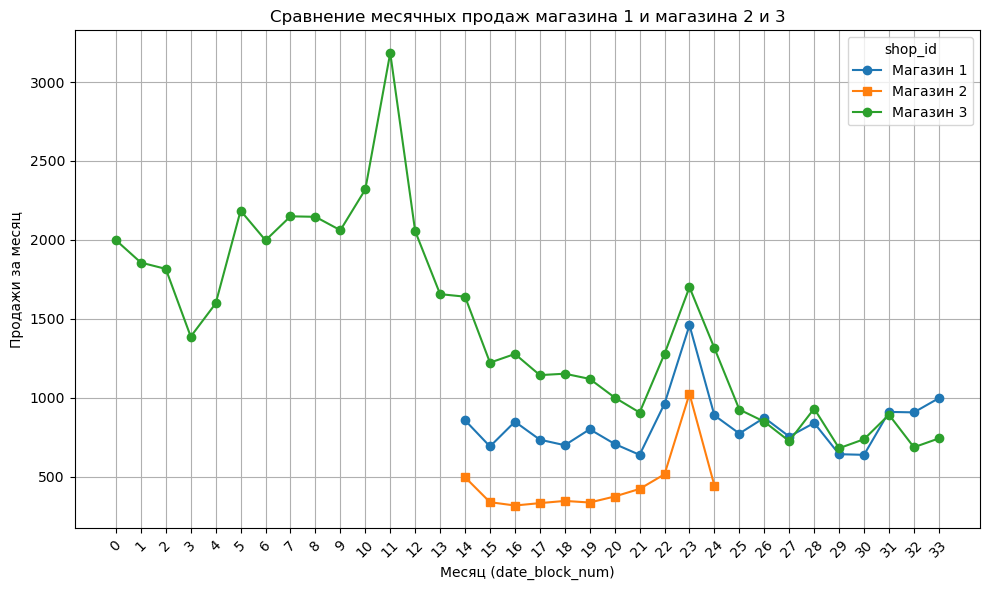

In [38]:
series1 = df_11.groupby('date_block_num')['item_cnt_day'].sum()
series2 = df_22.groupby('date_block_num')['item_cnt_day'].sum()
series3 = df_33.groupby('date_block_num')['item_cnt_day'].sum()

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    series1.index, 
    series1.values, 
    marker='o', 
    label='Магазин 1'
)
ax.plot(
    series2.index, 
    series2.values, 
    marker='s', 
    label='Магазин 2'
)
ax.plot(
    series3.index, 
    series3.values, 
    marker='o', 
    label='Магазин 3'
)
ax.set_xlabel('Месяц (date_block_num)')
ax.set_ylabel('Продажи за месяц')
ax.set_title('Сравнение месячных продаж магазина 1 и магазина 2 и 3')
ax.legend(title='shop_id')
ax.grid(True)

plt.xticks(
    sorted(set(series1.index) | set(series2.index) | set(series3.index)),
    rotation=45
)
plt.tight_layout()
plt.show()


Не одинаковые магазины

In [39]:
df_3 = df_1[df_1['shop_id']==10]
df_4 = df_1[df_1['shop_id']==11]

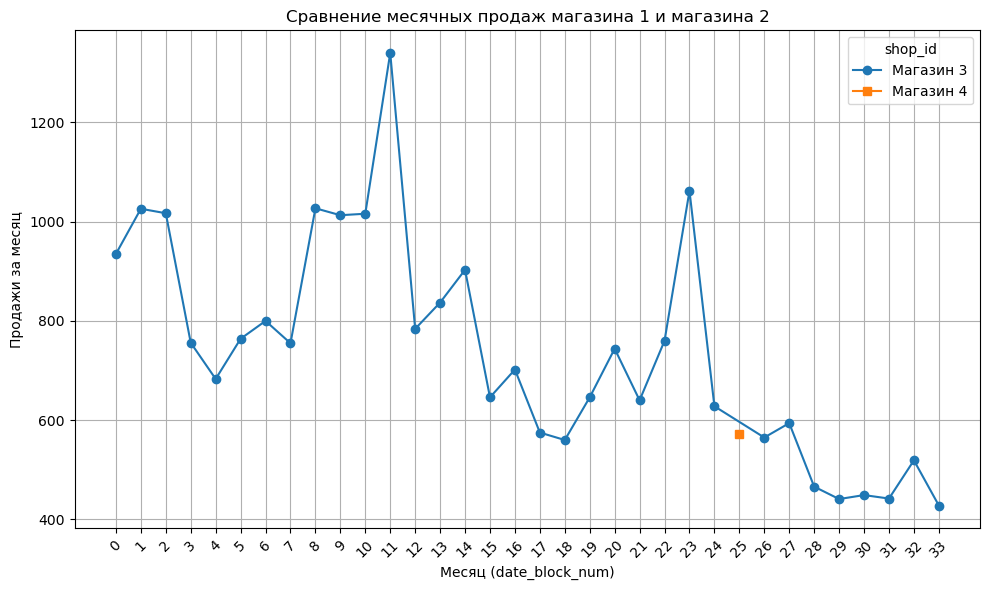

In [40]:
series1 = df_3.groupby('date_block_num')['item_cnt_day'].sum()
series2 = df_4.groupby('date_block_num')['item_cnt_day'].sum()

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    series1.index, 
    series1.values, 
    marker='o', 
    label='Магазин 3'
)
ax.plot(
    series2.index, 
    series2.values, 
    marker='s', 
    label='Магазин 4'
)

ax.set_xlabel('Месяц (date_block_num)')
ax.set_ylabel('Продажи за месяц')
ax.set_title('Сравнение месячных продаж магазина 1 и магазина 2')
ax.legend(title='shop_id')
ax.grid(True)

plt.xticks(
    sorted(set(series1.index) | set(series2.index)),
    rotation=45
)
plt.tight_layout()
plt.show()

Получаем вывод -  получается просто кто-то ошибся и ровно один месяц записал данные одного магазина создав другое название, без зазарения совести добавлю его туда, обьединив эти магазины 

In [41]:
# заменю и в df_1 и df_month
df_1.loc[
    df_1['shop_id'] == 11, 
    ['shop_id', 'shop_name']
] = [10, 'Жуковский ул. Чкалова 39м']

df_month.loc[
    df_month['shop_id'] == 11, 
    ['shop_id']
] = [10]


In [42]:
df_5 = df_1[df_1['shop_id']==0]
df_6 = df_1[df_1['shop_id']==57]



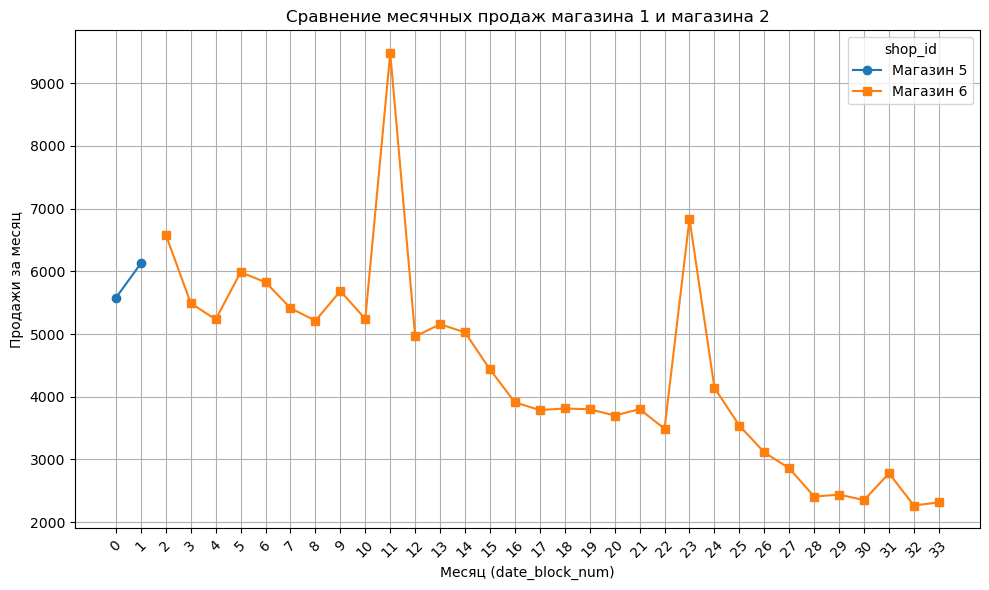

In [43]:
series1 = df_5.groupby('date_block_num')['item_cnt_day'].sum()
series2 = df_6.groupby('date_block_num')['item_cnt_day'].sum()

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    series1.index, 
    series1.values, 
    marker='o', 
    label='Магазин 5'
)
ax.plot(
    series2.index, 
    series2.values, 
    marker='s', 
    label='Магазин 6'
)

ax.set_xlabel('Месяц (date_block_num)')
ax.set_ylabel('Продажи за месяц')
ax.set_title('Сравнение месячных продаж магазина 1 и магазина 2')
ax.legend(title='shop_id')
ax.grid(True)

plt.xticks(
    sorted(set(series1.index) | set(series2.index)),
    rotation=45
)
plt.tight_layout()
plt.show()

In [44]:
df_1.loc[
    df_1['shop_id'] == 0, 
    ['shop_id', 'shop_name']
] = [57, 'Якутск Орджоникидзе, 56']

df_month.loc[
    df_month['shop_id'] == 0, 
    ['shop_id']
] = [57]

Мы нашли магазины, которые совпадают, изменили информацию о них в тренировочном датасете (в тестовом вообще нет магазинов, которые дублированы, я проверила)

In [45]:
selected = df_2[df_2['shop_id']==0] # собственно сама проверка 
selected

,ID,shop_id,item_id,item_name,item_category_id,item_category_name,shop_name


In [46]:
selected = df_2[df_2['shop_id']==11] # проверка 
selected

,ID,shop_id,item_id,item_name,item_category_id,item_category_name,shop_name


In [47]:
df_items.shape

(22170, 3)

Мы видим, что всего товаров у нас 22170, до этого я пробовала чистить товары и нашла, что 77 пар, в которых не понятно, разные ли это товары и стоит проверить статистически, но я считаю, что раз товаров повторяющихся так мало (всего 0.35%) я не считаю, что будет такой большой выхлоп от ее очистки 

In [48]:
df_month_test = df_2[['shop_id', 'item_id','item_category_id' ]]

In [49]:
df_month_test['date_block_num'] = 34
df_month_test.head()

C:\Users\Barys\AppData\Local\Temp\ipykernel_24668\4207175823.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_month_test['date_block_num'] = 34


,shop_id,item_id,item_category_id,date_block_num
0,5,5037,19,34
1,5,5320,55,34
2,5,5233,19,34
3,5,5232,23,34
4,5,5268,20,34


In [50]:
df_month.to_csv('df_train_dqc.csv', index=False)

In [51]:
df_month_test.to_csv('df_test_dqc.csv', index=False)

Далее к получившимся датасетам добавлю новые фичи, возможно модернизирую имеющиеся или выкину старые 